In [1]:
# ============================================================
# Setup
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import torch

import importlib
import functions3
importlib.reload(functions3)
import functions3 as fct

fct.set_seed(0)
device = fct.get_device()
print("Using device:", device)

Using device: mps


In [2]:
# ============================================================
# Bimodal target distribution: pi_D = 0.5 N(mu1, sigma^2 I) + 0.5 N(mu2, sigma^2 I)
# ============================================================
d = 2
mu1 = np.array([1.3, 1.3])
mu2 = np.array([-1.3, -1.3])
sigma_mix = 1.0
weight = 0.5

X_data_bimodal = fct.sample_bimodal_data(
    N=1_000_000, d=d, mu1=mu1, mu2=mu2, sigma=sigma_mix, weight=weight
)
true_mixture_mean = weight * mu1 + (1 - weight) * mu2

In [3]:
# ------------------------------------------------------------
# Sanity check: confirm empirical mean/std match theory before
# trusting anything trained on this data.
# Expected mean: [0, 0]. Expected std per dim: sqrt(weight*(1-weight) is
# not the formula here since weight=0.5 - see Var = 0.5*(sigma^2+mu^2)*2 = 13,
# i.e. std = sqrt(13) ~= 3.6056 for mu=2, sigma=3.
# ------------------------------------------------------------
print("True mixture mean:      ", true_mixture_mean)
print("Empirical mean per dim: ", X_data_bimodal.mean(axis=0))
print("Empirical std per dim:  ", X_data_bimodal.std(axis=0))
print("Expected std (theory):  ", np.sqrt(2 * (sigma_mix**2 + 2.0**2) / 2))

True mixture mean:       [0. 0.]
Empirical mean per dim:  [-0.00212099 -0.00264132]
Empirical std per dim:   [1.63917009 1.64004306]
Expected std (theory):   2.23606797749979


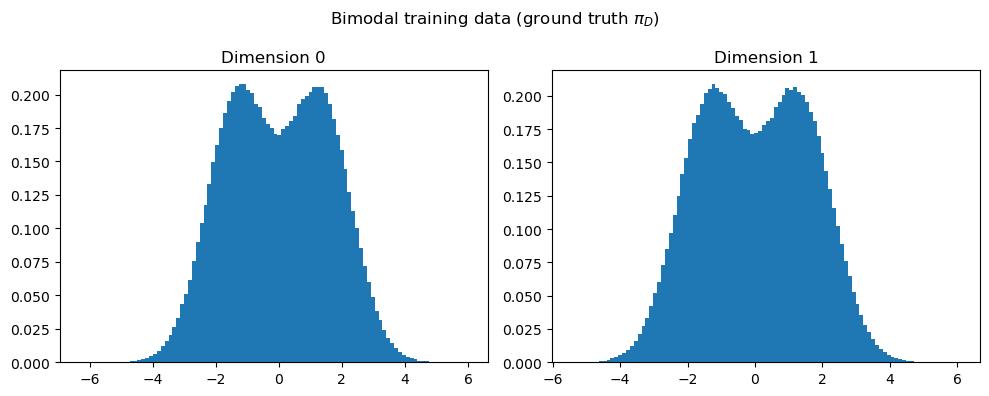

In [4]:
# ------------------------------------------------------------
# Visualise the target distribution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, density=True)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Bimodal training data (ground truth $\\pi_D$)")
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Train (Adam)
# ============================================================
T = 2

net_adam = fct.ScoreNet(d=d, D_1=128)   # swap for fct.ScoreNet3(d=d, D_1=128, D_2=128) to try the 3-layer net

net_adam, loss_history_adam = fct.train_network(
    net_adam, X_data_bimodal, t_0=1e-3, T=T, d=d,
    n_iters=20_000, batch_size=512, lr=1e-3,
    device=device, print_every=500
)

[Adam] iter 500/20000, loss = 1.4115
[Adam] iter 1000/20000, loss = 1.3983
[Adam] iter 1500/20000, loss = 1.0579
[Adam] iter 2000/20000, loss = 1.0829
[Adam] iter 2500/20000, loss = 4.0778
[Adam] iter 3000/20000, loss = 1.2927
[Adam] iter 3500/20000, loss = 1.3896
[Adam] iter 4000/20000, loss = 2.9360
[Adam] iter 4500/20000, loss = 1.6492
[Adam] iter 5000/20000, loss = 1.2708
[Adam] iter 5500/20000, loss = 1.1454
[Adam] iter 6000/20000, loss = 1.5954
[Adam] iter 6500/20000, loss = 1.2214
[Adam] iter 7000/20000, loss = 1.1213
[Adam] iter 7500/20000, loss = 1.7710
[Adam] iter 8000/20000, loss = 1.3455
[Adam] iter 8500/20000, loss = 1.7029
[Adam] iter 9000/20000, loss = 3.2369
[Adam] iter 9500/20000, loss = 2.1097
[Adam] iter 10000/20000, loss = 1.3783
[Adam] iter 10500/20000, loss = 1.6945
[Adam] iter 11000/20000, loss = 1.4025
[Adam] iter 11500/20000, loss = 1.4156
[Adam] iter 12000/20000, loss = 4.6594
[Adam] iter 12500/20000, loss = 1.8346
[Adam] iter 13000/20000, loss = 2.0790
[Adam]

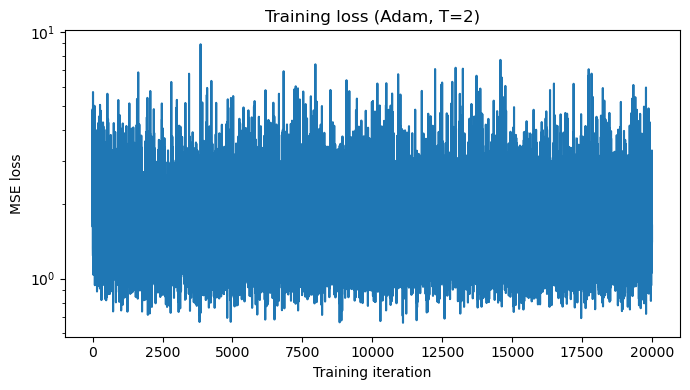

In [6]:
# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_history_adam)
plt.xlabel("Training iteration")
plt.ylabel("MSE loss")
plt.yscale('log')
plt.title(f"Training loss (Adam, T={T})")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Sample from the reverse SDE using the trained network
# ============================================================
N_samples = 1_000_000
samples_adam = fct.euler_maruyama_sample_nn_batch(
    net_adam, gamma=0.001, T=T, d=d, N_samples=N_samples, device=device
)

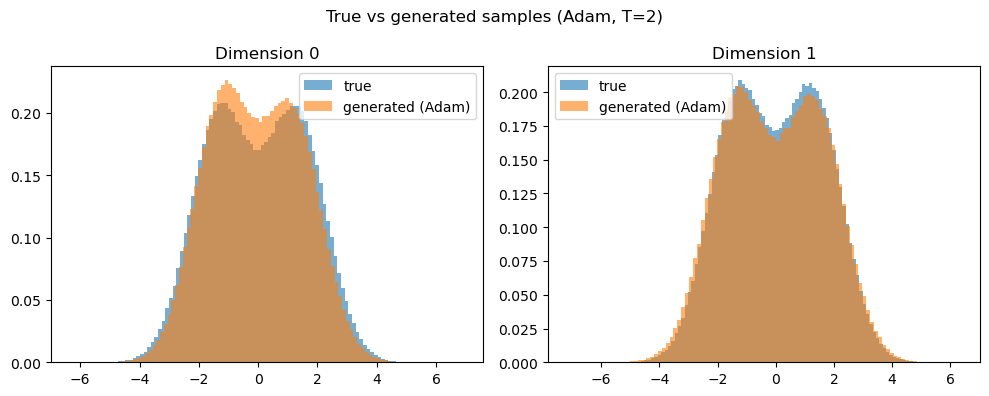

In [8]:
# ============================================================
# Compare true data distribution against generated samples
# ============================================================
fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.6, density=True, label="true")
    axes[i].hist(samples_adam[:, i], bins=100, alpha=0.6, density=True, label="generated (Adam)")
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
plt.suptitle(f"True vs generated samples (Adam, T={T})")
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# W2 between generated samples and true data
# ============================================================
N_w2 = 2000
w2_adam = fct.wasserstein2_distance(samples_adam[:N_w2], X_data_bimodal[:N_w2])
print(f"W2(generated [Adam], true) = {w2_adam:.4f}")

W2(generated [Adam], true) = 0.2558


In [10]:
# ------------------------------------------------------------
# Noise floor at the same N: W2 between two INDEPENDENT samples of
# pi_D itself. This is what w2_adam should be compared against - not zero.
# ------------------------------------------------------------
floor_mean, floor_std = fct.W2_self_floor(X_data_bimodal, N=N_w2, n_repeats=5)
print(f"W2 noise floor (pi_D vs pi_D, N={N_w2}) = {floor_mean:.4f} +/- {floor_std:.4f}")

W2 noise floor (pi_D vs pi_D, N=2000) = 0.1906 +/- 0.0049


In [11]:
# ============================================================
# Train (SGLD) - matches the Langevin recurrence used in the toy
# unknown-mean example, with H(theta) now computed via backprop
# through the network. See train_network_sgld docstring for the
# exact loss-scaling reasoning (sum over d, mean over batch).
# ============================================================
lam = 1e-4     # fixed step size - tune down if the loss diverges
beta = 1e6     # inverse temperature




net_sgld = fct.ScoreNet(d=d, D_1=128)   # same architecture as net_adam, for a fair comparison


kappa_sigma2 = lambda tau: 1 - np.exp(-2 * tau)   # kappa(t) = sigma_t^2

net_sgld, loss_history_sgld = fct.train_network_sgld(
    net_sgld, X_data_bimodal, t_0=1e-3, T=T, d=d,
    n_iters=5000, batch_size=512, lam=lam, beta=beta,
    device=device, kappa_fn=kappa_sigma2, print_every=500
)


[SGLD] iter 500/5000, loss = 1.2957
[SGLD] iter 1000/5000, loss = 0.9805
[SGLD] iter 1500/5000, loss = 0.8147
[SGLD] iter 2000/5000, loss = 0.8059
[SGLD] iter 2500/5000, loss = 0.8345
[SGLD] iter 3000/5000, loss = 0.7952
[SGLD] iter 3500/5000, loss = 0.7972
[SGLD] iter 4000/5000, loss = 0.7332
[SGLD] iter 4500/5000, loss = 0.7374
[SGLD] iter 5000/5000, loss = 0.7246


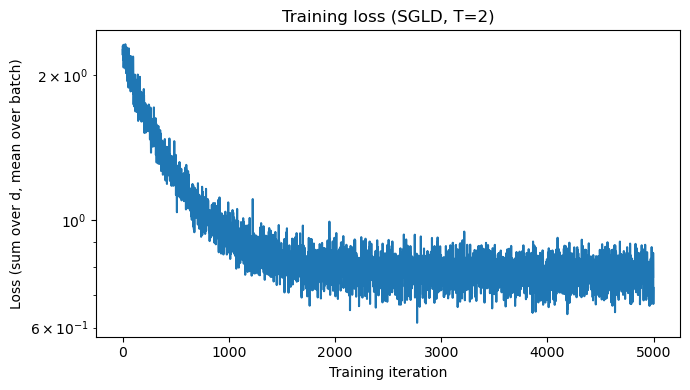

In [12]:
# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_history_sgld)
plt.xlabel("Training iteration")
plt.ylabel("Loss (sum over d, mean over batch)")
plt.yscale('log')
plt.title(f"Training loss (SGLD, T={T})")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Sample from the SGLD-trained network
# ============================================================
samples_sgld = fct.euler_maruyama_sample_nn_batch(
    net_sgld, gamma=0.001, T=T, d=d, N_samples=N_samples, device=device
)

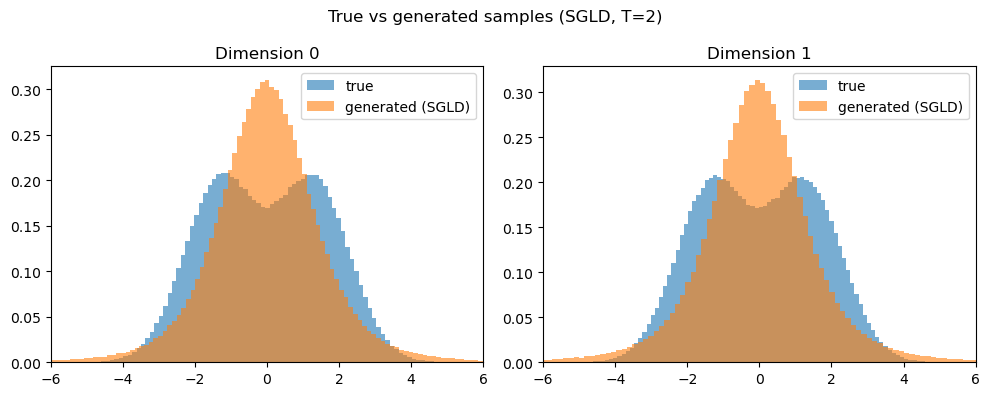

In [14]:
# ------------------------------------------------------------
# True vs generated (SGLD)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.6, density=True, label="true")
    axes[i].hist(samples_sgld[:, i], bins=300, alpha=0.6, density=True, label="generated (SGLD)")
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
    axes[i].set_xlim(-6, 6)   # zoom in to see the bimodal structure clearly
plt.suptitle(f"True vs generated samples (SGLD, T={T})")
plt.tight_layout()
plt.show()

In [15]:
# ------------------------------------------------------------
# W2 for the SGLD network
# ------------------------------------------------------------
w2_sgld = fct.wasserstein2_distance(samples_sgld[:N_w2], X_data_bimodal[:N_w2])
print(f"W2(generated [SGLD], true) = {w2_sgld:.4f}")

W2(generated [SGLD], true) = 0.8297


In [16]:
# ============================================================
# Direct comparison: same architecture, same T, same iteration count,
# same evaluation set - only the optimiser differs.
# ============================================================
print(f"{'Optimiser':<10} {'Final loss':<12} {'W2':<10}")
print(f"{'Adam':<10} {loss_history_adam[-1]:<12.4f} {w2_adam:<10.4f}")
print(f"{'SGLD':<10} {loss_history_sgld[-1]:<12.4f} {w2_sgld:<10.4f}")
print(f"{'floor':<10} {'-':<12} {floor_mean:<10.4f}")

Optimiser  Final loss   W2        
Adam       1.4174       0.2558    
SGLD       0.7246       0.8297    
floor      -            0.1906    


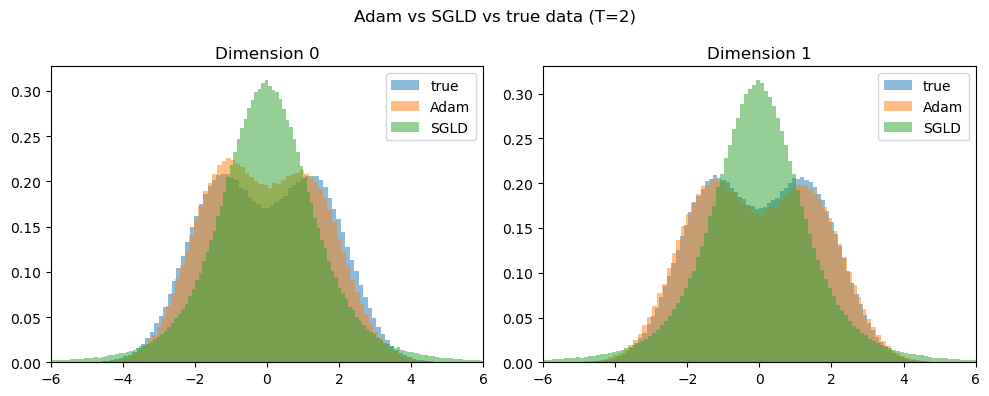

In [17]:
# ------------------------------------------------------------
# Overlaid true vs both generated sets, for a single visual comparison
# ------------------------------------------------------------
fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.5, density=True, label="true")
    axes[i].hist(samples_adam[:, i], bins=100, alpha=0.5, density=True, label="Adam")
    axes[i].hist(samples_sgld[:, i], bins=400, alpha=0.5, density=True, label="SGLD")
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
    axes[i].set_xlim(-6, 6)   # zoom in to see the bimodal structure clearly
plt.suptitle(f"Adam vs SGLD vs true data (T={T})")
plt.tight_layout()
plt.show()

In [18]:
net_tusla = fct.ScoreNet(d=d, D_1=128)

net_tusla, loss_history_tusla, param_norm_history_tusla = fct.train_network_tusla(
    net_tusla, X_data_bimodal, t_0=1e-3, T=T, d=d,
    n_iters=000, batch_size=512,
    lam=1e-4, beta=1e6, eta=1e-6, r=3,
    device=device, print_every=500
)

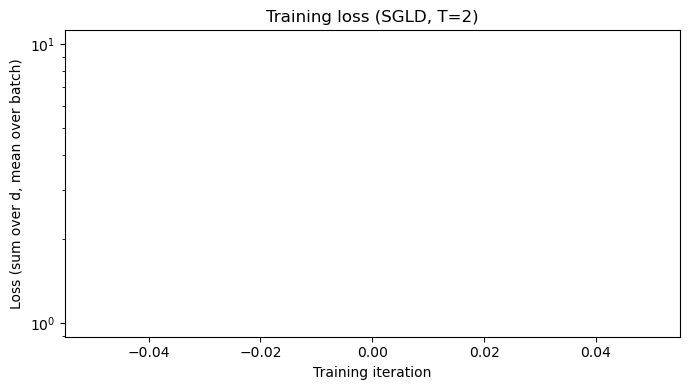

In [19]:
# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_history_tusla)
plt.xlabel("Training iteration")
plt.ylabel("Loss (sum over d, mean over batch)")
plt.yscale('log')
plt.title(f"Training loss (SGLD, T={T})")
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Sample from the TUSLA-trained network
# ============================================================
samples_tusla = fct.euler_maruyama_sample_nn_batch(
    net_tusla, gamma=0.001, T=T, d=d, N_samples=N_samples, device=device
)

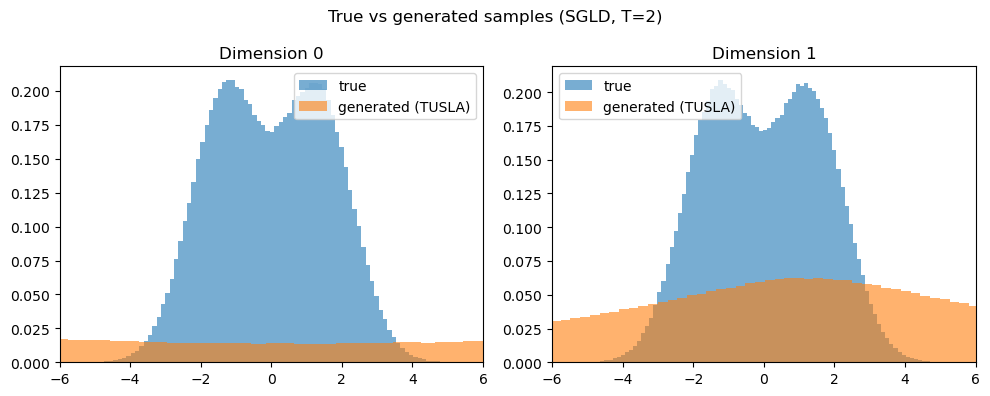

In [21]:
# ------------------------------------------------------------
# True vs generated (TUSLA)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.6, density=True, label="true")
    axes[i].hist(samples_tusla[:, i], bins=300, alpha=0.6, density=True, label="generated (TUSLA)")
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
    axes[i].set_xlim(-6, 6)   # zoom in to see the bimodal structure clearly
plt.suptitle(f"True vs generated samples (SGLD, T={T})")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Instantiate the 20-layer network (19 hidden layers + 1 output layer)
# ============================================================
net20_adam = fct.ScoreNetDeep(d=d, hidden_dims=[128] * 19)
net20_sgld = fct.ScoreNetDeep(d=d, hidden_dims=[128] * 19)

In [23]:
# ============================================================
# Train (Adam)
# ============================================================
T = 2

net20_adam, loss_history_20_adam = fct.train_network(
    net20_adam, X_data_bimodal, t_0=1e-3, T=T, d=d,
    n_iters=20000, batch_size=512, lr=1e-3,
    device=device, print_every=500
)

[Adam] iter 500/20000, loss = 1.2346
[Adam] iter 1000/20000, loss = 1.5966
[Adam] iter 1500/20000, loss = 1.1697
[Adam] iter 2000/20000, loss = 1.1126
[Adam] iter 2500/20000, loss = 1.2461
[Adam] iter 3000/20000, loss = 5.1933
[Adam] iter 3500/20000, loss = 1.7152
[Adam] iter 4000/20000, loss = 1.7892
[Adam] iter 4500/20000, loss = 1.3160
[Adam] iter 5000/20000, loss = 1.1832
[Adam] iter 5500/20000, loss = 3.3324
[Adam] iter 6000/20000, loss = 1.7922
[Adam] iter 6500/20000, loss = 1.1008
[Adam] iter 7000/20000, loss = 1.8781
[Adam] iter 7500/20000, loss = 0.9972
[Adam] iter 8000/20000, loss = 2.5099
[Adam] iter 8500/20000, loss = 1.6128
[Adam] iter 9000/20000, loss = 1.0440
[Adam] iter 9500/20000, loss = 1.1743
[Adam] iter 10000/20000, loss = 1.3499
[Adam] iter 10500/20000, loss = 1.4831
[Adam] iter 11000/20000, loss = 1.2939
[Adam] iter 11500/20000, loss = 1.2432
[Adam] iter 12000/20000, loss = 1.9557
[Adam] iter 12500/20000, loss = 1.6918
[Adam] iter 13000/20000, loss = 1.3900
[Adam]

In [24]:
# ============================================================
# Train (SGLD)
# ============================================================
lam = 1e-4
beta = 1e6

net20_sgld, loss_history_20_sgld = fct.train_network_sgld(
    net20_sgld, X_data_bimodal, t_0=1e-3, T=T, d=d,
    n_iters=20000, batch_size=512, lam=lam, beta=beta,
    device=device, print_every=500
)

[SGLD] iter 500/20000, loss = 4.6371
[SGLD] iter 1000/20000, loss = 6.9617
[SGLD] iter 1500/20000, loss = 4.5743
[SGLD] iter 2000/20000, loss = 5.3099
[SGLD] iter 2500/20000, loss = 5.4563
[SGLD] iter 3000/20000, loss = 5.3746
[SGLD] iter 3500/20000, loss = 5.4579
[SGLD] iter 4000/20000, loss = 4.1613
[SGLD] iter 4500/20000, loss = 5.6109
[SGLD] iter 5000/20000, loss = 4.3420
[SGLD] iter 5500/20000, loss = 4.9384
[SGLD] iter 6000/20000, loss = 4.0802
[SGLD] iter 6500/20000, loss = 6.4875
[SGLD] iter 7000/20000, loss = 4.9055
[SGLD] iter 7500/20000, loss = 7.0298
[SGLD] iter 8000/20000, loss = 5.4924
[SGLD] iter 8500/20000, loss = 4.5748
[SGLD] iter 9000/20000, loss = 5.8713
[SGLD] iter 9500/20000, loss = 4.3930
[SGLD] iter 10000/20000, loss = 8.7214
[SGLD] iter 10500/20000, loss = 5.2072
[SGLD] iter 11000/20000, loss = 4.3054
[SGLD] iter 11500/20000, loss = 4.5713
[SGLD] iter 12000/20000, loss = 4.2849
[SGLD] iter 12500/20000, loss = 4.3444
[SGLD] iter 13000/20000, loss = 3.4084
[SGLD]

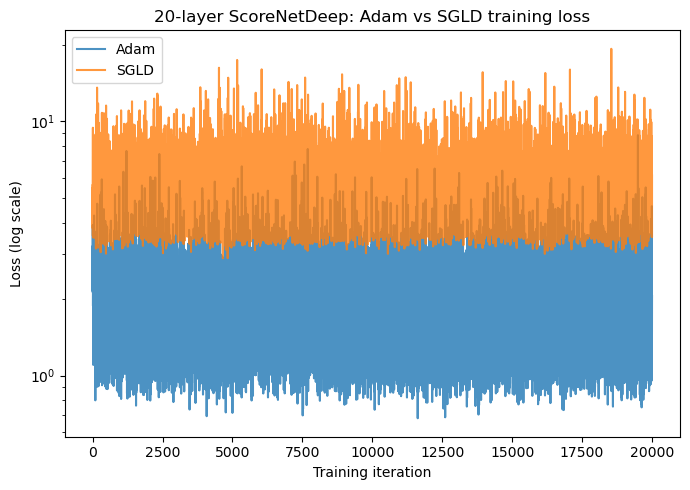

In [25]:
# ============================================================
# Loss curves, side by side
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(loss_history_20_adam, label="Adam", alpha=0.8)
plt.plot(loss_history_20_sgld, label="SGLD", alpha=0.8)
plt.yscale('log')
plt.xlabel("Training iteration")
plt.ylabel("Loss (log scale)")
plt.title("20-layer ScoreNetDeep: Adam vs SGLD training loss")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# Sample from both trained networks
# ============================================================
N_samples = 200_000

samples_20_adam = fct.euler_maruyama_sample_nn_batch(
    net20_adam, gamma=0.001, T=T, d=d, N_samples=N_samples, device=device
)
samples_20_sgld = fct.euler_maruyama_sample_nn_batch(
    net20_sgld, gamma=0.001, T=T, d=d, N_samples=N_samples, device=device
)

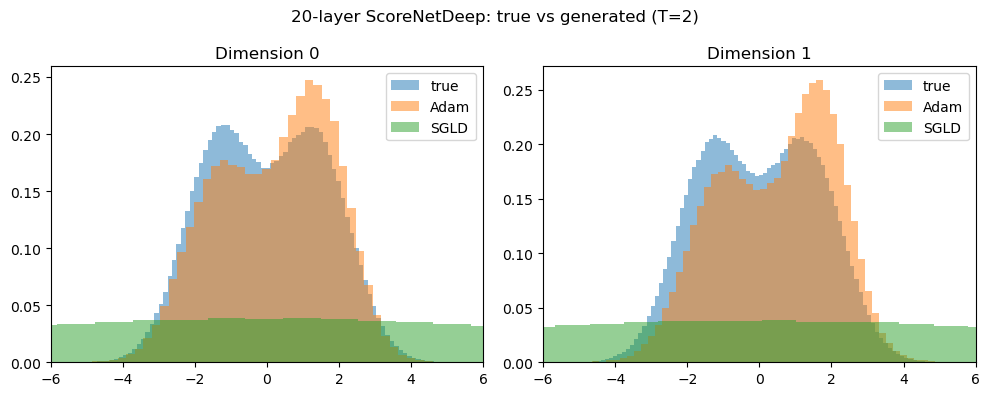

In [32]:
# ============================================================
# True vs generated, both optimisers
# ============================================================
fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.5, density=True, label="true")
    axes[i].hist(samples_20_adam[:, i], bins=100, alpha=0.5, density=True, label="Adam")
    axes[i].hist(samples_20_sgld[:, i], bins=100, alpha=0.5, density=True, label="SGLD")
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
    axes[i].set_xlim(-6, 6)   # zoom in to see the bimodal structure clearly
plt.suptitle(f"20-layer ScoreNetDeep: true vs generated (T={T})")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# W2 distance, both optimisers, plus the noise floor for reference
# ============================================================
N_w2 = 2000

w2_20_adam = fct.wasserstein2_distance(samples_20_adam[:N_w2], X_data_bimodal[:N_w2])
w2_20_sgld = fct.wasserstein2_distance(samples_20_sgld[:N_w2], X_data_bimodal[:N_w2])
floor_mean, floor_std = fct.W2_self_floor(X_data_bimodal, N=N_w2, n_repeats=5)

print(f"{'Model':<12} {'W2':<10}")
print(f"{'Adam':<12} {w2_20_adam:<10.4f}")
print(f"{'SGLD':<12} {w2_20_sgld:<10.4f}")
print(f"{'floor':<12} {floor_mean:<10.4f}")